In [2]:
import torch
import torch.nn as nn
import torch.optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
device = 'mps' if torch.mps.is_available() else 'cpu'
device

'mps'

In [4]:
# Hyperparameters
batch_size = 128
learning_rate = 1e-3
num_epochs = 10
noise_factor = 0.5

In [5]:
transform = transforms.ToTensor()
# Training dataset is setting here
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.63MB/s]


In [6]:
# test dataset is setting here
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [7]:
# train_loader and test_loader is setting here
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
# Guassian noise is added to the input images
def add_noise(images):
    noise = torch.randn_like(images) * noise_factor
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

In [9]:
# Autoencoder model is defined here
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        latent = self.encoder(x)
        output = self.decoder(latent)
        output = output.view(-1, 1, 28, 28)
        return output


In [10]:
# Model, loss function, and optimizer are defined here
model = DenoisingAutoencoder().to(device)

In [11]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [12]:
# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        # Add noise to the input images
        noisy_images = add_noise(images)

        # Forward pass
        outputs = model(noisy_images)
        loss = criterion(outputs, images)
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')
print('Training complete.')

Epoch [1/10], Loss: 0.0582
Epoch [2/10], Loss: 0.0329
Epoch [3/10], Loss: 0.0280
Epoch [4/10], Loss: 0.0255
Epoch [5/10], Loss: 0.0236
Epoch [6/10], Loss: 0.0224
Epoch [7/10], Loss: 0.0214
Epoch [8/10], Loss: 0.0206
Epoch [9/10], Loss: 0.0201
Epoch [10/10], Loss: 0.0195
Training complete.


In [13]:
# Testing
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    noisy_images = add_noise(images)
    reconstructed = model(noisy_images)

In [14]:
# Move to CPU for visualization
images = images.cpu()
noisy_images = noisy_images.cpu()
reconstructed = reconstructed.cpu()

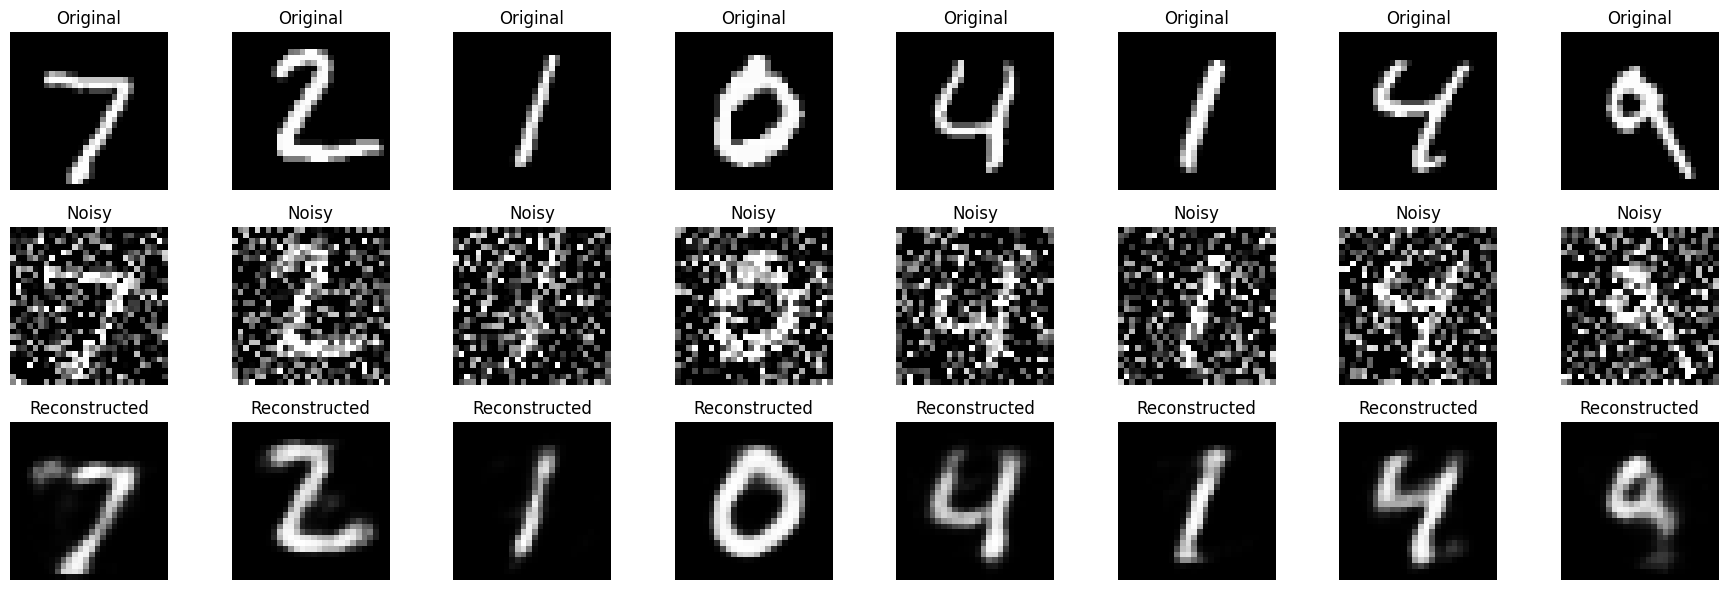

In [15]:
# Plot Results
plt.figure(figsize=(18, 6))

for i in range(8):
    # Original Image
    plt.subplot(3, 8, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Noisy Image
    plt.subplot(3, 8, i + 1 + 8)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title('Noisy')
    plt.axis('off')

    # Reconstructed Image
    plt.subplot(3, 8, i + 1 + 16)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')
plt.tight_layout()